In [1]:
# Import pandas for data manipulation.
import pandas as pd
# Create_engine from SQLAlchemy to establish a high-performance database connection.
from sqlalchemy import create_engine
# Import the Path class from pathlib
#for clean, cross-platform, object-oriented file path operations
from pathlib import Path
# Import text construct from SQLAlchemy 
#to execute safely formatted raw SQL queries inside engine connections
from sqlalchemy import text
# Import pyplot module from matplotlib for generating data visualizations.
import matplotlib.pyplot as plt
# Import seaborn library for advanced statistical data visualization.
import seaborn as sns
# Import numpy library for numerical operations.
import numpy as np

In [3]:
#Connection string
connection_string = (
    "mssql+pyodbc://localhost/master"
    "?driver=ODBC+driver+17+for+SQL+Server&trusted_connection=yes"
)

In [6]:
# Create a SQLAlchemy database engine instance using the specified connection string
engine = create_engine(connection_string)

In [10]:
#Path to folder containing CSVs
folder_path = Path("Ecommerce")

In [22]:
#Loop through every CSV file in the folder
for file_path in folder_path.glob("*.csv"):
    # Load CSV
    df = pd.read_csv(file_path)
    #Create a SEPARATE table for each file (using filename as table name) 
    #extracts just the filename without its extension and without its folder path.
    table_name = file_path.stem
    # Write the DataFrame directly into the target SQL database table using SQLAlchemy engine,
    #replacing existing data without writing DataFrame index as a column
    df.to_sql(table_name,con=engine,if_exists='replace',index=False)

C:\Users\Hassa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1125.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


#After fixing a lot of errors, 
#I now have no errors; however, 
#the loop finishes and everything runs smoothly, 
#but nothing happens and no table is created. I need to figure out the problem.

In [15]:
#Quick check If it prints an empty list [],That means the problem is probably with the path.
print(list(folder_path.glob("*.csv")))

[]


that confirms the path issue.

In [17]:
print(Path.cwd())

C:\Users\Hassa\OneDrive\Desktop\Data Analysis\Ecommerce


My notebook is already running inside the Ecommerce folder,
so Path("Ecommerce") looks for an Ecommerce subfolder inside Ecommerce, 
which doesn't exist.

In [21]:
#"." means "current directory" 
#so this points to wherever the notebook is running (which is already the Ecommerce folder).
folder_path = Path(".")

In [25]:
#Verify changes.
print(pd.read_sql("select table_name from information_schema.tables",con=engine))

               table_name
0               customers
1             geolocation
2                  orders
3             order_items
4                payments
5         spt_fallback_db
6                products
7        spt_fallback_dev
8                 sellers
9        spt_fallback_usg
10  MSreplication_options
11             spt_values
12            spt_monitor


In [26]:
# Iterate through directory CSV files,
# load each into a DataFrame,
# and print missing value counts per column for initial data validation.
for file_path in folder_path.glob("*.csv"):
    print(f"Processing {file_path.name}")
    df = pd.read_csv(file_path)
    print("NaN values before replacement:")
    print(df.isna().sum())
    print()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing geolocation.csv
NaN values before replacement:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing order_items.csv
NaN values before replacement:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit

In [7]:
# Connect to master database to issue a raw SQL DDL command creating the target database,
with engine.connect().execution_options(isolation_level="AUTOCOMMIT") as conn:
    conn.execute(text("create database Ecommerce"))

C:\Users\Hassa\AppData\Local\Temp\ipykernel_10936\2474714510.py:3: SAWarning: Unrecognized server version info '17.0.1125.2'.  Some SQL Server features may not function properly.
  with engine.connect().execution_options(isolation_level="AUTOCOMMIT") as conn:


In [4]:
#Connect to the new database
ecommerce_engine = create_engine(
    "mssql+pyodbc://localhost/Ecommerce"
    "?driver=ODBC+driver+17+for+SQL+Server&trusted_connection=yes"
)

In [9]:
#copy each table
tables=["customers", "geolocation", "order_items", "orders", "payments", "products", "sellers"]
# Extract tables from source database using pandas read_sql
#and load them into destination database using target engine instance
for table in tables:
    df = pd.read_sql(f"select * from {table}",con=engine)
    df.to_sql(table,con=ecommerce_engine,if_exists="replace",index=False)
    print(f"Moved {table}")

C:\Users\Hassa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1125.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Moved customers
Moved geolocation
Moved order_items
Moved orders
Moved payments
Moved products
Moved sellers


In [11]:
#Drop the tables from the master database.
with engine.connect().execution_options(isolation_level="AUTOCOMMIT") as conn:
    for table in tables:
        conn.execute(text(f"drop table {table}"))
        print(f"Dropped {table} from master")

Dropped customers from master
Dropped geolocation from master
Dropped order_items from master
Dropped orders from master
Dropped payments from master
Dropped products from master
Dropped sellers from master


In [5]:
# Establish a database connection configured with AUTOCOMMIT isolation level
#to execute DDL operations without explicit transaction management
conn = ecommerce_engine.connect().execution_options(isolation_level="AUTOCOMMIT")

C:\Users\Hassa\AppData\Local\Temp\ipykernel_13360\1324181436.py:3: SAWarning: Unrecognized server version info '17.0.1135.8'.  Some SQL Server features may not function properly.
  conn = ecommerce_engine.connect().execution_options(isolation_level="AUTOCOMMIT")


In [19]:
conn.execute(text("select top 5 * from payments"))

That output means the query succeeded.
In SQLAlchemy,
conn.execute() returns an unread cursor result object
(an iterator holding the query's raw memory pointer).
To actually display or extract the data rows,
i need to call a fetch method or load it into Pandas.

In [31]:
conn.execute(text("select top 5 * from payments")).fetchall()

[('b81ef226f3fe1789b1e8b2acac839d17', 1, 'credit_card', 8, 99.33),
 ('a9810da82917af2d9aefd1278f1dcfa0', 1, 'credit_card', 1, 24.39),
 ('25e8ea4e93396b6fa0d3dd708e76c1bd', 1, 'credit_card', 1, 65.71),
 ('ba78997921bbcdc1373bb41e913ab953', 1, 'credit_card', 8, 107.78),
 ('42fdf880ba16b47b59251dd489d4441a', 1, 'credit_card', 2, 128.45)]

In [38]:
conn.execute(text("select top 5 * from customers")).fetchall()

[('06b8999e2fba1a1fbc88172c00ba8bc7', '861eff4711a542e4b93843c6dd7febb0', 14409, 'franca', 'SP'),
 ('18955e83d337fd6b2def6b18a428ac77', '290c77bc529b7ac935b93aa66c333dc3', 9790, 'sao bernardo do campo', 'SP'),
 ('4e7b3e00288586ebd08712fdd0374a03', '060e732b5b29e8181a18229c7b0b2b5e', 1151, 'sao paulo', 'SP'),
 ('b2b6027bc5c5109e529d4dc6358b12c3', '259dac757896d24d7702b9acbbff3f3c', 8775, 'mogi das cruzes', 'SP'),
 ('4f2d8ab171c80ec8364f7c12e35b23ad', '345ecd01c38d18a9036ed96c73b8d066', 13056, 'campinas', 'SP')]

In [39]:
#Everything is working fine.

# List all unique cities where customers are located.

In [42]:
#First, take a look at the table columns.
conn.execute(text("""select column_name from information_schema.columns
where table_name='customers'""")).fetchall()

[('customer_id',),
 ('customer_unique_id',),
 ('customer_zip_code_prefix',),
 ('customer_city',),
 ('customer_state',)]

In [29]:
#The answer.
query = conn.execute(text("select distinct customer_city from customers"))
df = pd.DataFrame(query.fetchall())
df.head()#Here, I used `head()` to shorten the result.

,customer_city
0,abaiara
1,abdon batista
2,abaira
3,abare
4,abaetetuba


# Count the number of orders placed in 2017.

In [46]:
#First, take a look at the table columns.
conn.execute(text("""select column_name from information_schema.columns
where table_name='orders'""")).fetchall()

[('order_id',),
 ('customer_id',),
 ('order_status',),
 ('order_purchase_timestamp',),
 ('order_approved_at',),
 ('order_delivered_carrier_date',),
 ('order_delivered_customer_date',),
 ('order_estimated_delivery_date',)]

In [49]:
#The answer.
conn.execute(text("""
select count(order_id) from orders where Year(order_purchase_timestamp)=2017
""")).fetchall()

[(45101,)]

# Find the total sales per category.

In [52]:
#First, take a look at the table columns.
conn.execute(text("""
select column_name from information_schema.columns where table_name='payments'
""")).fetchall()

[('order_id',),
 ('payment_sequential',),
 ('payment_type',),
 ('payment_installments',),
 ('payment_value',)]

In [15]:
#The answer.
conn.execute(text("""
select upper(products.[product category]) category,
round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by upper(products.[product category])
""")).fetchall()

[('AUDIO', 60324.62),
 ('AUTOMOTIVE', 852294.33),
 ('CLIMATIZATION', 91170.66),
 ('CONSTRUCTION TOOLS ILLUMINATION', 72712.48),
 ('DRINK FOODS', 27289.73),
 ('DRINKS', 71429.65),
 ('ELECTRONICS', 259857.1),
 ('FASHION UNDERWEAR AND BEACH FASHION', 12714.54),
 ('ARTS AND CRAFTS', 2326.17),
 ('ART', 30992.93),
 (None, 252801.71),
 ('BAGS ACCESSORIES', 187151.29),
 ('AGRO INDUSTRIA E COMERCIO', 118730.61),
 ('BED TABLE BATH', 1712553.67),
 ('FLOWERS', 2213.01),
 ('FURNITURE OFFICE', 646826.49),
 ('IMPORTED BOOKS', 6701.89),
 ('LA CUISINE', 2913.53),
 ('MARKET PLACE', 45335.92),
 ('SPORT LEISURE', 1392127.56),
 ('STATIONARY STORE', 317440.07),
 ('BABIES', 539845.66),
 ('CINE PHOTO', 9530.32),
 ('CONSTRUCTION SECURITY TOOLS', 65691.03),
 ('CONSTRUCTION TOOLS GARDEN', 42394.41),
 ('ELECTROSTILE', 225584.38),
 ('FASHION BAGS AND ACCESSORIES', 218158.28),
 ('HOUSE COMFORT', 84329.06),
 ('INSURANCE AND SERVICES', 324.51),
 ('PCS', 279121.55),
 ('BLU RAY DVDS', 7935.28),
 ('CASA CONSTRUCAO', 136

In [23]:
querry = text("""
SELECT 
    UPPER(products.[product category]) AS category,
    ROUND(SUM(order_items.price), 2) AS sales
FROM products 
JOIN order_items ON products.product_id = order_items.product_id
GROUP BY UPPER(products.[product category])
""")
df = pd.read_sql(querry,con=ecommerce_engine)
df

,category,sales
0,ART,24202.64
1,BLU RAY DVDS,5999.39
2,CASA CONSTRUCAO,83088.12
3,BED TABLE BATH,1036988.68
4,CDS MUSIC DVDS,730.00
...,...,...
69,PET SHOP,214315.41
70,ROOM FURNITURE,68916.56
71,SONG,6034.35
72,PCS,222963.13


# Calculate the percentage of orders that were paid in installments.

In [23]:
#First, take a look at the payments table columns.
conn.execute(text("""
select column_name from information_schema.columns where table_name='payments'
""")).fetchall()

[('order_id',),
 ('payment_sequential',),
 ('payment_type',),
 ('payment_installments',),
 ('payment_value',)]

In [41]:
#The answer.
conn.execute(text("""
select (sum(case when payment_installments>=1 then 1 else 0 end)/count(0))*100 from payments
""")).fetchall()

[(0,)]

This returns 0 because of Integer Division in SQL Server.
In SQL Server,
when i divide an integer by another integer,
SQL Server truncates the result to an integer.
Since the numerator(count of installment payments) is smaller than the denominator(COUNT(*)),
the actual decimal result is rounded down to 0.

In [43]:
#Force decimal division by multiplying numerator by 1.0
conn.execute(text("""
select (sum(case when payment_installments>=1 then 1.0 else 0 end)/count(0))*100 from payments
""")).fetchall()

[(Decimal('99.998000'),)]

# Count the number of customers from each state.

In [46]:
#First, take a look at the customers table columns.
conn.execute(text("""
select column_name from information_schema.columns where table_name='customers'
""")).fetchall()

[('customer_id',),
 ('customer_unique_id',),
 ('customer_zip_code_prefix',),
 ('customer_city',),
 ('customer_state',)]

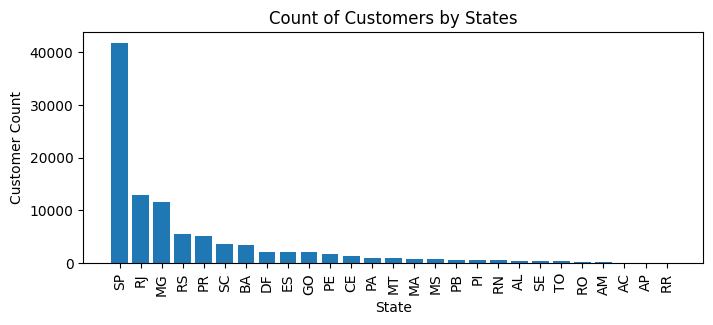

In [71]:
#The answer.
query = conn.execute(text("""
select customer_state as state,count(customer_id) as customer_count
from customers
group by customer_state
"""))
df = pd.DataFrame(query.fetchall(),columns=query.keys())
df = df.sort_values(by="customer_count",ascending=False)
plt.figure(figsize=(8,3))
plt.bar(df['state'],df['customer_count'])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Customer Count")
plt.title("Count of Customers by States")
plt.show()

# Calculate the number of orders per month in 2018.

In [73]:
#First, take a look at the orders table columns.
conn.execute(text("""
select column_name from information_schema.columns
where table_name = 'orders'
""")).fetchall()

[('order_id',),
 ('customer_id',),
 ('order_status',),
 ('order_purchase_timestamp',),
 ('order_approved_at',),
 ('order_delivered_carrier_date',),
 ('order_delivered_customer_date',),
 ('order_estimated_delivery_date',)]

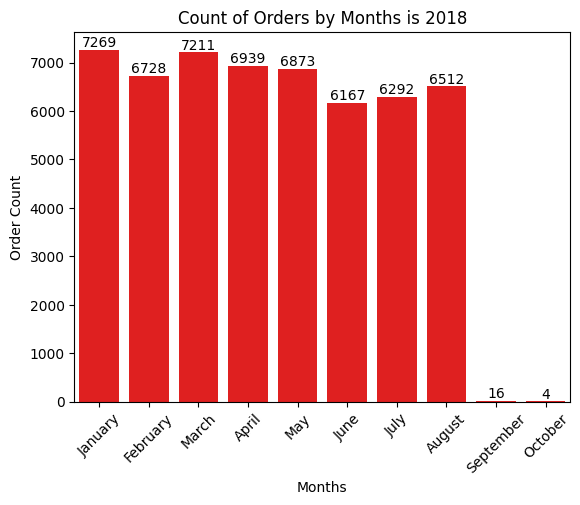

In [100]:
#The answer.
query = conn.execute(text("""
select datename(month,order_purchase_timestamp) Months,count(order_id) "Order Count"
from orders
where year(order_purchase_timestamp)=2018
group by datename(month,order_purchase_timestamp),month (order_purchase_timestamp)
order by month(order_purchase_timestamp)
"""))
df = pd.DataFrame(query.fetchall(),columns=["Months","Order Count"])
ax = sns.barplot(x=df['Months'],y=df['Order Count'],data=df,color="red")
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months is 2018")
plt.show()

# Find the average number of products per order, grouped by customer city.

In [107]:
#The answer.
query = conn.execute(text("""
with count_per_order as(
select orders.order_id,orders.customer_id,count(order_items.order_id)*1.0 oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id
)




select customers.customer_city, cast(avg(count_per_order.oc) as decimal(10,2)) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""))
df = pd.DataFrame(query.fetchall(),columns=['Customer City','Average Products/Order'])
df.head(5)

,Customer City,Average Products/Order
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00


# Calculate the percentage of total revenue contributed by each product category.

In [116]:
#First, take a look at the products table columns.
conn.execute(text("""
select column_name from information_schema.columns where table_name='products'
""")).fetchall()

[('product_id',),
 ('product category',),
 ('product_name_length',),
 ('product_description_length',),
 ('product_photos_qty',),
 ('product_weight_g',),
 ('product_length_cm',),
 ('product_height_cm',),
 ('product_width_cm',)]

In [121]:
#The answer.
query = conn.execute(text("""
select upper(products.[product category]) Category,
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by upper(products.[product category]) order by sales_percentage desc
""")) 
df = pd.DataFrame(query.fetchall(),columns=['Category','Percentage Distribution'])
df.head()

,Category,Percentage Distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,WATCHES PRESENT,8.93
4,FURNITURE DECORATION,8.93


# Identify the correlation between product price and the number of times a product has been purchased.

In [138]:
query = conn.execute(text("""
select "product category", count(products.product_id),round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by "product category"
"""))
df = pd.DataFrame(query.fetchall(),columns=['Category','Order Count','Price'])
arr1 = df['Order Count']
arr2 = df['Price']
a = np.corrcoef([arr1,arr2])
print("the correlation is",a[0][1])

the correlation is -0.10631514167157563


# Calculate the total revenue generated by each seller, and rank them by revenue.

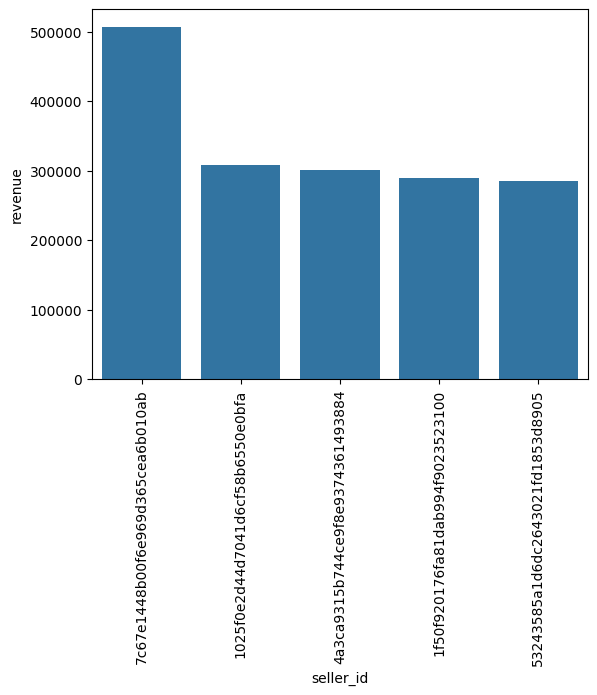

In [143]:
query = conn.execute(text("""
select *,dense_rank() over(order by revenue desc) rn
from
(select order_items.seller_id,sum(payments.payment_value) revenue
from order_items 
join
payments
on
order_items.order_id = payments.order_id
group by order_items.seller_id) a
"""))
df = pd.DataFrame(query.fetchall(),columns=['seller_id','revenue','rank'])
df = df.head()
sns.barplot(x="seller_id",y="revenue",data = df)
plt.xticks(rotation=90)
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [158]:
query = conn.execute(text("""
with customer_payments as(
select o.customer_id,
o.order_purchase_timestamp,
p.payment_value as payment
from orders o join payments p
on o.order_id = p.order_id
)
select customer_id,
order_purchase_timestamp,
payment,
avg(payment) over(
partition by customer_id
order by order_purchase_timestamp
rows between 2 preceding and current row
)moving_average
from customer_payments
ORDER BY customer_id, order_purchase_timestamp
"""))
df = pd.DataFrame(query.fetchall())
df

,customer_id,order_purchase_timestamp,payment,moving_average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.74
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.41
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.42
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.35
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.01
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.12
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.13
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.13
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.50


# Calculate the cumulative sales per month for each year.

In [179]:
query = conn.execute(text("""
with monthly_sales as (
select year(o.order_purchase_timestamp) years, month(o.order_purchase_timestamp) months, 
round(sum(p.payment_value),2) payment
from 
orders o
join
payments p
on
o.order_id = p.order_id
group by 
year(o.order_purchase_timestamp),
month(o.order_purchase_timestamp)
)
select years, months, payment, sum(payment) over (order by years, months) cumulative_sales
from monthly_sales
order by years, months
"""))
df = pd.DataFrame(query.fetchall())
df

,years,months,payment,cumulative_sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


In [232]:
#Added indexes to reduce query execution time 
conn.execute(text("""
create index ix_payments_order_id
on
payments(order_id)
create index ix_orders_order_id
on
orders(order_id)
"""))
#This error occurs
#because SQL Server cannot build an index on a VARCHAR(MAX) or NVARCHAR(MAX) column,
#which is the default type Pandas uses when importing text columns into SQL Server.
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️

ProgrammingError: (pyodbc.ProgrammingError) ('42000', "[42000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Column 'order_id' in table 'payments' is of a type that is invalid for use as a key column in an index. (1919) (SQLExecDirectW)")
[SQL: 
create index ix_payments_order_id
on
payments(order_id)
create index ix_orders_order_id
on
orders(order_id)
]
(Background on this error at: https://sqlalche.me/e/20/f405)

In [233]:
# Check maximum character length of order_id in both tables
# to select a safe size for VARCHAR before creating indexes.
query = conn.execute(text("""
select 'orders' as table_name, max(len(order_id)) max_char_length
from orders
union all
select 'payments' table_name, max(len(order_id)) max_char_length
from payments
"""))
df = pd.DataFrame(query.fetchall())
df

,table_name,max_char_length
0,orders,32
1,payments,32


Both tables max out at 32 characters

In [235]:
#Alter order_id to VARCHAR(50) to make it indexable
conn.execute(text("""
--Resize order_id columns to a fixed, indexable length
alter table orders alter column order_id varchar(50) not null
alter table payments alter column order_id varchar(50) not null
"""))

In [6]:
    #Verify changes.
query = conn.execute(text("""
select column_name,data_type,character_maximum_length from information_schema.columns
where column_name = 'order_id'
and table_name in ('orders','payments')
"""))
df = pd.DataFrame(query.fetchall())
df

,column_name,data_type,character_maximum_length
0,order_id,varchar,50
1,order_id,varchar,50


In [242]:
query = conn.execute(text("""
--Create performance indexes
create index ix_orders_order_id on orders(order_id)
create index ix_payments_order_id on payments(order_id)
"""))

In [243]:
    # Query SQL Server system catalog views (sys.indexes and sys.tables)
    # to verify that the newly created non-clustered indexes exist
    # on the 'orders' and 'payments' tables.
query = conn.execute(text("""
select 
t.name as table_name,
i.name as index_name,
i.type_desc as index_type
from sys.indexes i
join sys.tables t on i.object_id = t.object_id
where t.name in ('orders','payments') and i.name is not null
"""))
df = pd.DataFrame(query.fetchall())
df
# Like a book index, a non-clustered index stores dedicated lookup pointers 
# to optimize JOINs and WHERE clauses without reordering physical table rows.

,table_name,index_name,index_type
0,orders,ix_orders_order_id,NONCLUSTERED
1,payments,ix_payments_order_id,NONCLUSTERED


# Calculate the year-over-year growth rate of total sales.

In [8]:
# Calculate Year-over-Year (YoY) revenue growth percentage by joining orders 
# and payments, using LAG window function to compare each year against the previous.
query = conn.execute(text("""
with yearly_payments as (
select
    year(o.order_purchase_timestamp) as years,
    sum(p.payment_value) as payment
from
    orders o
join
    payments p
on
    o.order_id = p.order_id
group by
    year(o.order_purchase_timestamp)
)
select
    years,
    ((payment - lag(payment,1) over(order by years))/lag(payment,1) over(order by years))*100.0 AS [yoy % growth]
from
    yearly_payments
order by
    years
"""))
df = pd.DataFrame(query.fetchall())
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [16]:
query = conn.execute(text("""
with customer_first_orders as(
select c.customer_unique_id, min(o.order_purchase_timestamp) as first_order
from customers c join orders o on c.customer_id = o.customer_id
group by c.customer_unique_id
),
repeat_customers as (
select
f.customer_unique_id,
count(distinct o.order_id) as next_orders -- COUNT(o.order_id) gives the same result here; DISTINCT prevents fan-out if order_items is joined later
from customer_first_orders f
join customers c on f.customer_unique_id = c.customer_unique_id
join orders o on c.customer_id = o.customer_id
where o.order_purchase_timestamp > f.first_order
and o.order_purchase_timestamp < dateadd(month,6,f.first_order)
group by f.customer_unique_id
)
select
100.0*count(distinct r.customer_unique_id) / count(distinct f.customer_unique_id) AS retention_rate_pct
from customer_first_orders f
left join repeat_customers r on f.customer_unique_id = r.customer_unique_id
"""))
df = pd.DataFrame(query.fetchall(),columns=query.keys())
df

,retention_rate_pct
0,2.324758574758


# Identify the top 3 customers who spent the most money in each year.

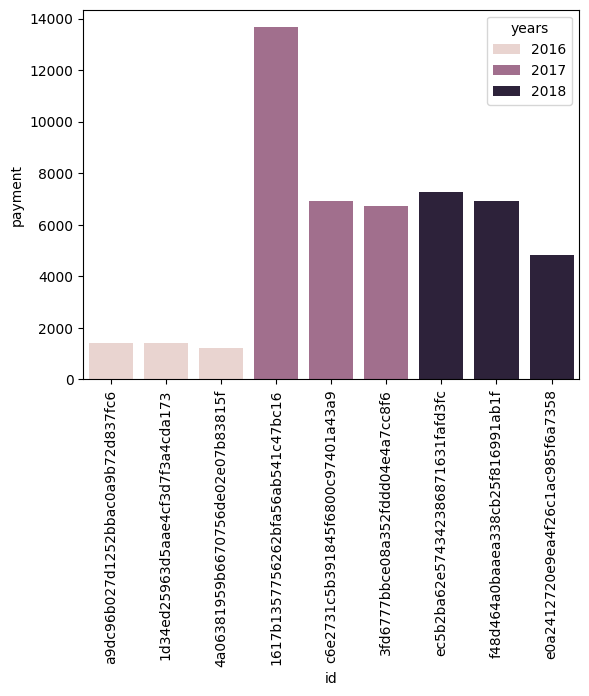

In [22]:
query = conn.execute(
    text("""
    WITH customer_spending AS (
        SELECT
            YEAR(o.order_purchase_timestamp) AS order_year,
            o.customer_id,
            SUM(p.payment_value) AS total_payment,
            DENSE_RANK() OVER (
                PARTITION BY YEAR(o.order_purchase_timestamp)
                ORDER BY SUM(p.payment_value) DESC
            ) AS spending_rank
        FROM orders o
        JOIN payments p ON o.order_id = p.order_id
        GROUP BY YEAR(o.order_purchase_timestamp), o.customer_id
    )
    SELECT 
        order_year, 
        customer_id, 
        total_payment, 
        spending_rank
    FROM customer_spending
    WHERE spending_rank <= 3
    ORDER BY order_year ASC, spending_rank ASC;
""")
)

data = query.fetchall()
df = pd.DataFrame(data, columns=["years", "id", "payment", "rank"])

sns.barplot(x="id", y="payment", data=df, hue="years", dodge=False)
plt.xticks(rotation=90)
plt.show()